# Machine Learning project autumn 2024

Authors: Dimitar Kochev, Mihael Stoyanov <br>

Reqired imports:



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA, IncrementalPCA
from sklearn.preprocessing import StandardScaler
from sklearn import tree
#import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten,Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.metrics import SparseCategoricalAccuracy
from sklearn.model_selection import cross_validate
from sklearn.model_selection import GroupKFold
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, recall_score, classification_report, confusion_matrix
import pickle
from sklearn.model_selection import GridSearchCV
from collections import Counter


# Exploratory data analysis

### Load data:

In [2]:
train_data = np.load('Data+Description\\fashion_train.npy')
test_data = np.load('Data+Description\\fashion_test.npy')

In [3]:
# Devide features and labels
train_data_X=train_data[:,:-1]
train_data_y=train_data[:,-1]
train_data_X=train_data_X / 255.0 #Scale pixel values to [0, 1]
test_data_X=test_data[:,:-1]
test_data_y=test_data[:,-1]

## Visualisations
### Distribution of classes in train set

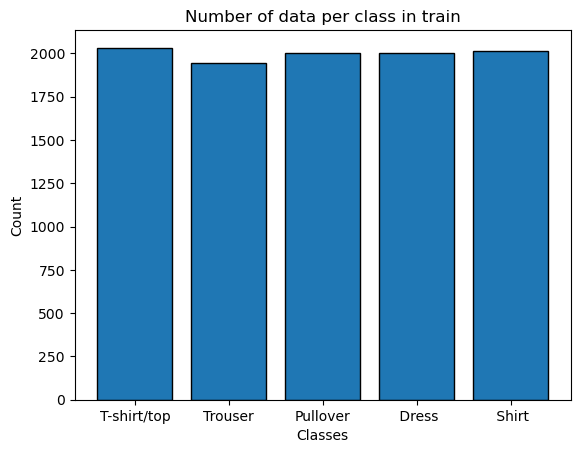

In [4]:
categories = ['T-shirt/top', 'Trouser', 'Pullover', ' Dress', ' Shirt']

# Plot the histogram
plt.hist(train_data_y, bins=np.arange(6)-0.5, edgecolor='black', rwidth=0.8)

# Set the x-ticks to the class names
plt.xticks(ticks=np.arange(5), labels=categories)

# Add labels and title
plt.xlabel('Classes')
plt.ylabel('Count')
plt.title('Number of data per class in train')

# Show the plot
plt.show()

### Dimensionality reduction with PCA

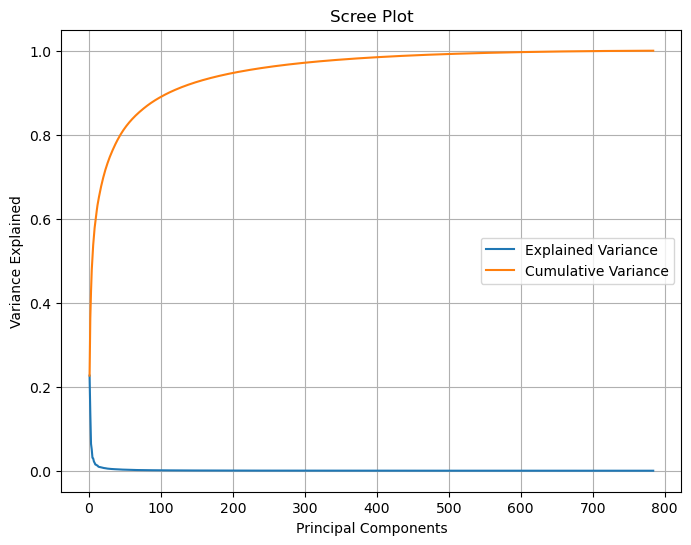

In [ ]:
#PCA on whole data

scaler = StandardScaler()
image_scaled = scaler.fit_transform(train_data_X)

# Apply PCA
pca = PCA()
pca.fit(image_scaled)

# Scree plot - Explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8, 6))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, label='Explained Variance')
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, label='Cumulative Variance')
plt.title('Scree Plot')
plt.xlabel('Principal Components')
plt.ylabel('Variance Explained')
plt.legend(loc='best')
plt.grid(True)
plt.show()

### Class distribution in 2 components space

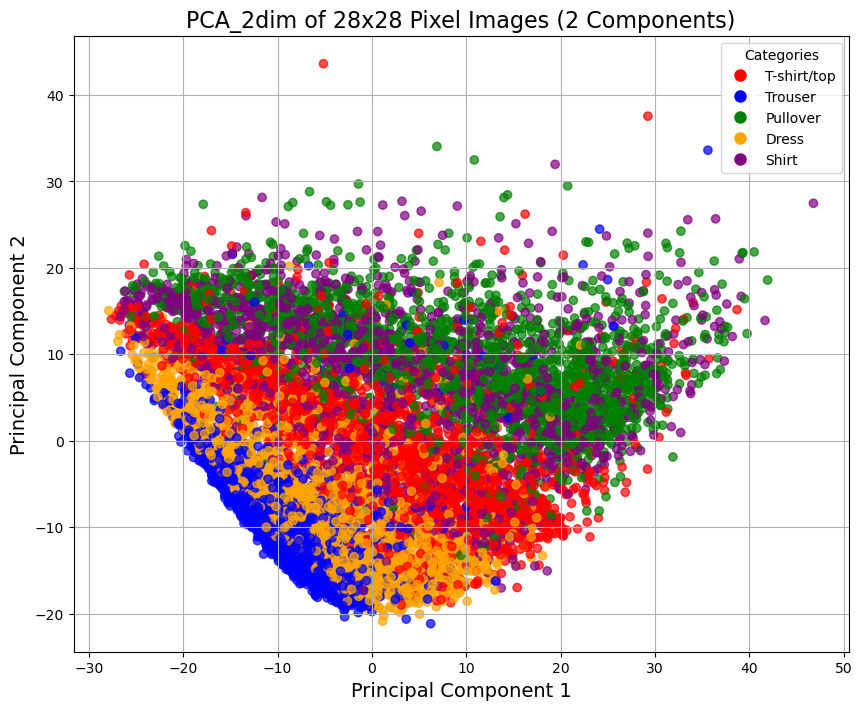

In [12]:
X_scaled = scaler.fit_transform(train_data_X)
pca_2dim = PCA(n_components=2)  # Reduce to 2 dimensions for visualization
principal_components = pca_2dim.fit_transform(X_scaled)

# Step 6: Convert to DataFrame for easier plotting
principal_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

# Step 7: Define colors for each category
categories = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Shirt']
colors = ['red', 'blue', 'green', 'orange', 'purple']  # Colors corresponding to categories

# Map the categories to colors
color_map = {i: colors[i] for i in range(len(categories))}
point_colors = [color_map[int(label)] for label in train_data_y]  # Assign colors based on the labels

# Step 8: Visualize the PCA_2dim results in 2D
plt.figure(figsize=(10, 8))
plt.scatter(principal_df['PC1'], principal_df['PC2'], 
            alpha=0.7, c=point_colors)

# Labels and title
plt.title('PCA_2dim of 28x28 Pixel Images (2 Components)', fontsize=16)
plt.xlabel('Principal Component 1', fontsize=14)
plt.ylabel('Principal Component 2', fontsize=14)

# Create a legend
import matplotlib.lines as mlines
legend_handles = [mlines.Line2D([], [], marker='o', color='w', 
                                  label=categories[i], 
                                  markerfacecolor=colors[i], 
                                  markersize=10) for i in range(len(categories))]
plt.legend(handles=legend_handles, title='Categories')

plt.grid()
plt.show()


Example for an image with different components

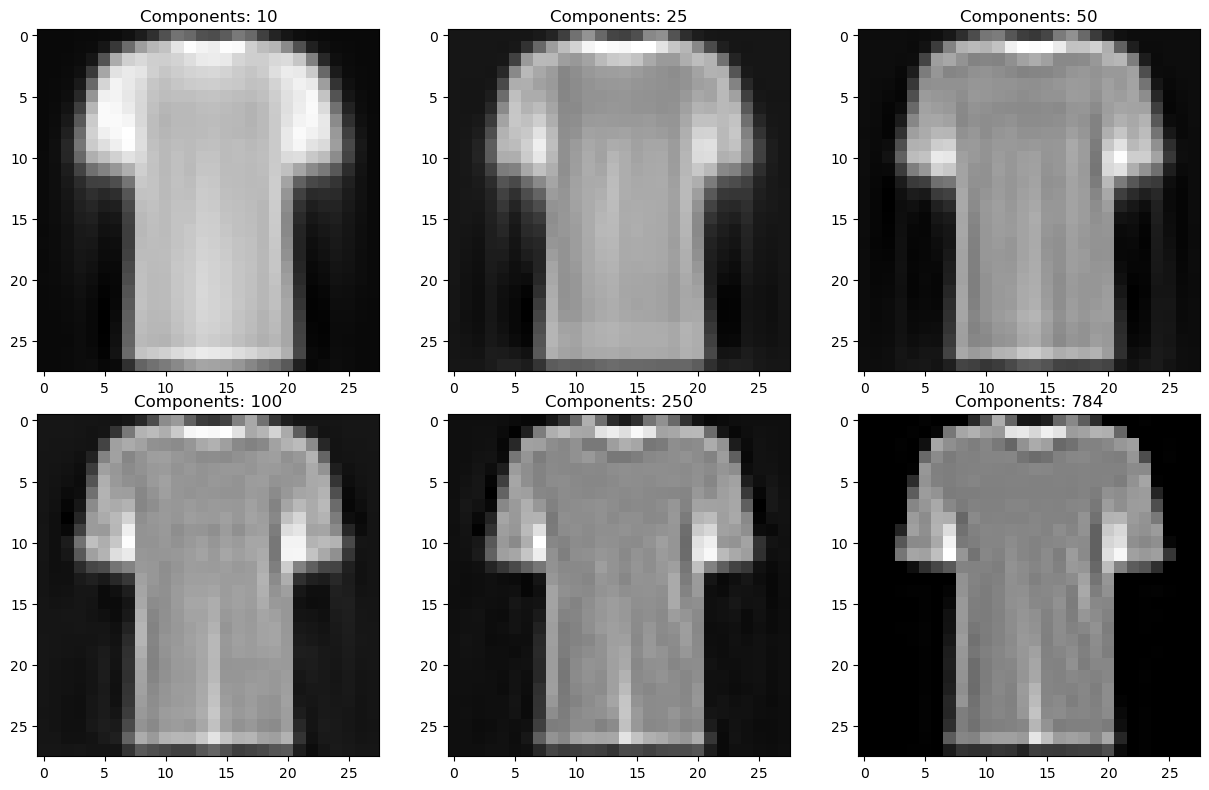

In [14]:
def plot_at_k(k):
    ipca = IncrementalPCA(n_components=k)
    image_recon = ipca.inverse_transform(ipca.fit_transform(train_data_X))[0].reshape(28,28)
    plt.imshow(image_recon,cmap = plt.cm.gray)

ks = [10, 25, 50, 100, 250, 784]
plt.figure(figsize=[15,10])

for i in range(6):
    plt.subplot(2,3,i+1)
    plot_at_k(ks[i])
    plt.title("Components: "+str(ks[i]))

plt.subplots_adjust(wspace=0.2, hspace=0.0)
plt.show()

We chose to use 50 components. The reason behind this is that we want to have a relativly low number of features but also to retain high variance. In 50 components we retain 81.6% of the original information. So we concider this as a good combination.

In [5]:
#We save our PCA for external analysis and 

pca_50dim = PCA(n_components=50)
X_reduced = pca_50dim.fit_transform(train_data_X)  # Transforms data to 50 components

# Step 2: Pickle the fitted PCA model
with open("pca_model_50_components.pkl", "wb") as file:
    pickle.dump(pca_50dim, file)

# Classification models

## 1.Manual implementations
### 1.1 Decicion tree

Our implementation:

In [8]:

class TreeNode:
    def __init__(self, data, feature_idx, feature_val, prediction_probs):
        self.data = data
        self.feature_idx = feature_idx
        self.feature_val = feature_val
        self.prediction_probs = prediction_probs
        self.left = None
        self.right = None

    def node_def(self):
        unique_values, value_counts = np.unique(self.data[:, -1], return_counts=True)
        output = ", ".join([f"{value}->{count}" for value, count in zip(unique_values, value_counts)])
        return f"LEAF | Label Counts = {output} | Pred Probs = {self.prediction_probs}"

class DecisionTreeFromScratch:
    def __init__(self, max_depth, min_leaf):
        self.max_depth = max_depth
        self.min_leaf = min_leaf
        self.tree = None

    def _entropy(self, class_probabilities):
        return sum([-p * np.log2(p) for p in class_probabilities if p > 0])

    def _class_probabilities(self, labels):
        total_count = len(labels)
        return [count / total_count for count in Counter(labels).values()]

    def _data_entropy(self, labels):
        return self._entropy(self._class_probabilities(labels))

    def _partition_entropy(self, subsets):
        total_count = sum(len(subset) for subset in subsets)
        return sum(self._data_entropy(subset) * (len(subset) / total_count) for subset in subsets)

    def _split_indices(self, data, feature_index, feature_val):
        mask = data[:, feature_index] < feature_val
        return np.where(mask)[0], np.where(~mask)[0]

    def _find_best_split(self, data):
        min_part_entropy = float('inf')
        best_split = None
        n_features = data.shape[1] - 1  # Exclude label column

        for idx in range(n_features):
            feature_vals = np.percentile(data[:, idx], q=np.linspace(0, 100, num=20))  # Optimize thresholds
            for feature_val in feature_vals:
                left_idx, right_idx = self._split_indices(data, idx, feature_val)
                if len(left_idx) == 0 or len(right_idx) == 0:  # Skip invalid splits
                    continue
                part_entropy = self._partition_entropy([data[left_idx, -1], data[right_idx, -1]])
                if part_entropy < min_part_entropy:
                    min_part_entropy = part_entropy
                    best_split = (left_idx, right_idx, idx, feature_val, min_part_entropy)

        return best_split if best_split else (None, None, None, None, None)

    def _find_label_probs(self, labels):
        total_labels = len(labels)
        label_probabilities = np.zeros(len(self.labels_in_train), dtype=float)
        for i, label in enumerate(self.labels_in_train):
            count = np.sum(labels == label)
            label_probabilities[i] = count / total_labels
        return label_probabilities

    def _create_tree(self, data, indices, current_depth):
        if current_depth >= self.max_depth or len(indices) < self.min_leaf:
            return None

        split = self._find_best_split(data[indices])
        if not split:
            return None

        left_idx, right_idx, split_feature_idx, split_feature_val, _ = split
        left_data_indices = indices[left_idx]
        right_data_indices = indices[right_idx]
        label_probabilities = self._find_label_probs(data[indices, -1])

        node = TreeNode(data[indices], split_feature_idx, split_feature_val, label_probabilities)
        if len(left_data_indices) < self.min_leaf or len(right_data_indices) < self.min_leaf:
            return node

        current_depth += 1
        node.left = self._create_tree(data, left_data_indices, current_depth)
        node.right = self._create_tree(data, right_data_indices, current_depth)
        return node

    def _predict_one_sample(self, X):
        node = self.tree
        while node.left or node.right:
            if X[node.feature_idx] < node.feature_val:
                node = node.left
            else:
                node = node.right
        return node.prediction_probs

    def fit(self, X_train, Y_train):
        self.labels_in_train = np.unique(Y_train)
        train_data = np.concatenate((X_train, np.reshape(Y_train, (-1, 1))), axis=1)
        indices = np.arange(len(train_data))
        self.tree = self._create_tree(data=train_data, indices=indices, current_depth=0)

    def predict_proba(self, X_set):
        return np.apply_along_axis(self._predict_one_sample, 1, X_set)

    def predict(self, X_set):
        pred_probs = self.predict_proba(X_set)
        return np.argmax(pred_probs, axis=1)

    def evaluate_model(self, X_val, y_val, labels):
        predictions = self.predict(X_val)
        accuracy = accuracy_score(y_val, predictions)
        recall_per_class = recall_score(y_val, predictions, average=None, labels=labels)
        return accuracy, recall_per_class

# Main Code: Data Loading and Cross-Validation
train_data = np.load('Data+Description/fashion_train.npy')
train_data_X = train_data[:, :-1]
train_data_y = train_data[:, -1]

with open("pca_model_50_components.pkl", "rb") as file:
    pca_loaded = pickle.load(file)

X_new_reduced = pca_loaded.transform(train_data_X)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_accuracies = []
fold_recalls = []
i=0
for train_index, val_index in kf.split(X_new_reduced):
    i+=1
    print("Fold", i)
    X_train, X_val = X_new_reduced[train_index], X_new_reduced[val_index]
    y_train, y_val = train_data_y[train_index], train_data_y[val_index]

    tree = DecisionTreeFromScratch(max_depth=13, min_leaf=12)
    tree.fit(X_train, y_train)
    labels = np.unique(y_train)

    accuracy, recall_per_class = tree.evaluate_model(X_val, y_val, labels)
    fold_accuracies.append(accuracy)
    fold_recalls.append(recall_per_class)

# Print Final Results
print("\nFinal Cross-Validation Results")
print(f"Mean Accuracy: {np.mean(fold_accuracies):.2f}")
print("Mean Recall per Class:", np.mean(fold_recalls, axis=0))

Fold 1
Fold 2
Fold 3
Fold 4
Fold 5

Final Cross-Validation Results
Mean Accuracy: 0.77
Mean Recall per Class: [0.74907829 0.92064659 0.78671996 0.83341152 0.55853923]


### 1.2 Feed-forward neural network

Our implementation:

In [ ]:
#define neural network layer
class Layer():
    def __init__(self, n_num, input_dim):
        self.weights = self.initialize_parameters(n_num, input_dim)
        

    def initialize_parameters(self, n_num, input_dim):
        """Initialize parameters with He initialization method"""
        
        parameters = {}
        parameters["W"] = np.random.randn(n_num, input_dim) * np.sqrt(2/input_dim)
        parameters["b"] = np.zeros((n_num, 1))

        return parameters
    
class Adam_optimizer():
    def __init__(self, learning_rate, beta1, beta2, epsilon, decay_rate):
        self.momentum_w = {}
        self.momentum_b = {}
        self.rms_w = {}
        self.rms_b = {}
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.learning_rate = learning_rate
        self.decay_rate = decay_rate  # Added decay rate
        self.t = 0  # Time step for bias correction


    def update_parameters(self, parameters, gradients, epoch):#(self, t, l_num, b, dw, db):
    
        self.t += 1
        decayed_learning_rate = self.learning_rate * np.exp(-self.decay_rate * epoch)
        
        # Update parameters for each layer
        for l_num, l in enumerate(parameters, start=1):
            # Initialize caches if not already present
            if l_num not in self.momentum_w:
                self.momentum_w[l_num] = np.zeros_like(parameters[l_num-1][0].weights['W'])
                self.momentum_b[l_num] = np.zeros_like(parameters[l_num-1][0].weights['b'])
                self.rms_w[l_num] = np.zeros_like(parameters[l_num-1][0].weights['W'])
                self.rms_b[l_num] = np.zeros_like(parameters[l_num-1][0].weights['b'])
            # Momentum updates
            self.momentum_w[l_num] = self.beta1 * self.momentum_w[l_num] + (1 - self.beta1) * gradients["dW" + str(l_num)]
            self.momentum_b[l_num] = self.beta1 * self.momentum_b[l_num] + (1 - self.beta1) * gradients["db" + str(l_num)]
            
            # RMS updates
            self.rms_w[l_num] = self.beta2 * self.rms_w[l_num] + (1 - self.beta2) * (gradients["dW" + str(l_num)]**2)
            self.rms_b[l_num] = self.beta2 * self.rms_b[l_num] + (1 - self.beta2) * (gradients["db" + str(l_num)]**2)
            
            # Bias correction
            momentum_w_corr = self.momentum_w[l_num] / (1 - self.beta1**self.t)
            momentum_b_corr = self.momentum_b[l_num] / (1 - self.beta1**self.t)
            rms_w_corr = self.rms_w[l_num] / (1 - self.beta2**self.t)
            rms_b_corr = self.rms_b[l_num] / (1 - self.beta2**self.t)

            # Update weights and biases
            l[0].weights['W'] -= decayed_learning_rate * (momentum_w_corr / (np.sqrt(rms_w_corr) + self.epsilon))
            l[0].weights['b'] -= decayed_learning_rate * (momentum_b_corr / (np.sqrt(rms_b_corr) + self.epsilon))
            
        return parameters

class Mini_Batch_GD_optimizer():
    def __init__(self, learning_rate, decay_rate=0.01):
        self.learning_rate=learning_rate
        self.decay_rate=decay_rate
    
    def update_parameters(self, parameters, gradients, epoch):
        decayed_learning_rate = self.learning_rate * np.exp(-self.decay_rate * epoch)
        l_num=0
        for l in parameters:
            l[0].weights['W'] -= decayed_learning_rate * gradients["dW"+str(l_num)]
            l[0].weights['b'] -= decayed_learning_rate * gradients["db"+str(l_num)]
            l_num+=1
        return parameters
    
#define fnn    
class FFNN():
    def __init__(self):
        self.layers=[]
        self.optimizer=None
        self.metrics={}
        #self.weights = []
    
    def add_layer(self, n_num, input_dim=None, activation="relu"):
        if input_dim is None:
            if len(self.layers) == 0:
                raise ValueError("Input dimension must be provided for the first layer.")
            input_dim = len(self.layers[-1][0].weights['W'])
        new_layer = Layer(n_num, input_dim)
        self.layers.append([new_layer, activation])
    def compile(self, optimizer='adam', learning_rate=0.001, beta1=0.9, beta2=0.999, epsilon=1e-8, decay_rate=0.01, metrics=['accuracy']):
        if optimizer=='adam':
            self.optimizer=Adam_optimizer(learning_rate, beta1, beta2, epsilon, decay_rate)
        elif optimizer=='mini':
            self.optimizer=Mini_Batch_GD_optimizer(learning_rate, decay_rate)
        for m in metrics: self.metrics.update({m : []})
        
        
    def fit(self, X_train, Y_train, batch_size, epochs=0):

        self.minibatch_size = batch_size
        temp_weights=self.layers.copy()
        for i in range(epochs):
            for batch_idx in range(0, int(X_train.shape[0] / batch_size)):
                # Mini Batch Samples
                if batch_idx == int(X_train.shape[1] / batch_size):
                    X = X_train[:, batch_idx*batch_size:]
                    Y = Y_train[:, batch_idx*batch_size:]
                else:
                    X = X_train[:, batch_idx*batch_size: (batch_idx+1)*batch_size]
                    Y = Y_train[:, batch_idx*batch_size: (batch_idx+1)*batch_size]
                output_history=self.feed_forward(temp_weights, X)
                prediction= output_history["A"+str(len(temp_weights))]
                self.get_stats(prediction, Y)
                
                gradients = self.backward_prop(temp_weights, output_history, Y)
                temp_weights = self.optimizer.update_parameters(temp_weights, gradients, epoch=i)
        self.layers=temp_weights
        

    
    def feed_forward(self, temp_weights, I):
        
        forward_vars = {"A0": I}
        for l_num in range(1,len(temp_weights)+1): 
            layer = temp_weights[l_num - 1] 
            forward_vars["Z"+str(l_num)] = np.dot(layer[0].weights['W'], forward_vars["A"+str(l_num-1)]) + layer[0].weights['b']
                
            if l_num == len(self.layers): 
                    forward_vars["A"+str(l_num)] = self._activate(forward_vars["Z"+str(l_num)], layer[1]) #output layer 
            else: 
                    forward_vars["A"+str(l_num)] = self._activate(forward_vars["Z"+str(l_num)], layer[1]) #hidden layers 
            l_num+=1        
        return forward_vars

    def backward_prop(self, parameters, forward_vars, Y):
        gradients = {}
        l_num=len(self.layers)
        for l_num in range(len(parameters), 0, -1):
            m = forward_vars["A"+str(l_num-1)].shape[1]
            
            layer = parameters[l_num - 1]
            if layer[1] == 'sigmoid':
                gradients["dA" + str(l_num)] = -np.divide(Y, forward_vars["A" + str(l_num)]) + np.divide((1 - Y), (1 - forward_vars["A" + str(l_num)]))
                gradients["dZ" + str(l_num)] = gradients["dA" + str(l_num)] * forward_vars["A" + str(l_num)] * (1 - forward_vars["A" + str(l_num)])
            # other activations
            elif layer[1] == 'relu':
                relu_derivative = forward_vars["A"+str(l_num)] > 0
                gradients["dZ"+str(l_num)] = np.multiply(gradients["dA"+str(l_num)], relu_derivative)
            elif layer[1] == 'softmax':
                gradients["dZ"+str(l_num)] = forward_vars["A"+str(l_num)] - Y 

            gradients["dW" + str(l_num)] = (1 / m) * np.dot(gradients["dZ" + str(l_num)], forward_vars["A" + str(l_num - 1)].T)
            gradients["db" + str(l_num)] = (1 / m) * np.sum(gradients["dZ" + str(l_num)], axis=1, keepdims=True)
            gradients["dA" + str(l_num - 1)] = np.dot(layer[0].weights['W'].T, gradients["dZ" + str(l_num)])
        return gradients
    
    def predict(self, X):
            """Predict labels for given data X"""
            forward_vars = self.feed_forward(self.layers, X)
            
            L = len(self.layers)
            return forward_vars["A"+str(L)]
    
    def _activate(self, I, activation):
        
        if activation=='relu':
            result=np.maximum(0, I)
        elif activation=='softmax':
            T = np.exp(I - np.max(I, axis=0, keepdims=True))
            T_sum = np.sum(T, axis=0, keepdims=True)
            result = np.divide(T, T_sum)
        elif activation=='sigmoid':
            result = 1 / (1 + np.exp(-I))
        else:
            print("Error")
        return result
    
    def get_stats(self, Y_hat, Y, num_classes=5):
        """
        Log Loss is applied
        """
    
        
        # Count correct predictions
        correct_predictions = np.sum(Y == Y_hat)
        total_predictions = len(Y)
        
        # Calculate accuracy
       
        TP = np.zeros(num_classes, dtype=int)
        FN = np.zeros(num_classes, dtype=int)
        
        # Calculate TP and FN for each class
        for i in range(num_classes):
            TP[i] = np.sum((Y == i) & (Y_hat == i))  # True Positives for class i
            FN[i] = np.sum((Y == i) & (Y_hat != i))  # False Negatives for class i
        
        # Calculate recall for each class
        recall_per_class = {}
        for i in range(num_classes):
            if TP[i] + FN[i] == 0:
                recall_per_class[i] = 0.0  # Avoid division by zero
            else:
                recall_per_class[i] = TP[i] / (TP[i] + FN[i])
        
        m = Y.shape[1]
        self.metrics['loss'].append((1/m) * np.sum(-(Y * np.log(Y_hat + 1e-15))))
        self.metrics['accuracy'].append(correct_predictions / total_predictions)
        self.metrics['recall'].append(recall_per_class)
 

Model building

In [ ]:
def create_multiclass_model_from_scratch(input_dim, num_classes):
    model = FFNN()
    model.add_layer(256, input_dim=input_dim, activation='relu') # First hidden layer
    model.add_layer(128, activation='relu') # First hidden layer
    model.add_layer(64, activation='relu')  # Second hidden layer
    model.add_layer(32, activation='relu')  # Third hidden layer
    model.add_layer(num_classes, activation='softmax')  # Output layer for multi-class classification
  
    # Compile the model
    model.compile(optimizer='adam',learning_rate=0.001,
                 #loss='sparse_categorical_crossentropy',  # or 'categorical_crossentropy' if using one-hot encoding
                 metrics=['accuracy', 'loss', 'recall'])
    return model

5-fold cross-validation with raw data

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_accuracies = []
all_classification_reports = []
all_confusion_matrices = []
def one_hot_encode(Y, num_classes):
    return np.eye(num_classes)[Y]

for fold, (train_index, val_index) in enumerate(kf.split(train_data_X)):
    print(f"Training fold {fold + 1}")
    
    # Split the data into training and validation sets for the current fold
    X_train, X_val = train_data_X[train_index].T, train_data_X[val_index].T
    y_train, y_val = train_data_y[train_index], train_data_y[val_index]
    y_train = one_hot_encode(y_train, 5).T
   
    #print(y_train)
    #y_train=y_train.reshape(1,len(y_train))
    #y_val=y_val.reshape(1,len(y_val))
    # Create a new instance of the model
    model = create_multiclass_model_from_scratch(input_dim=train_data_X.shape[1], num_classes=len(np.unique(train_data_y)))
    #print(X_val.shape, X_train.shape)
    # Train the model
    model.fit(X_train, y_train, epochs=100, batch_size=32)
    
    # Evaluate the model on the validation set
    y_val_pred = np.argmax(model.predict(X_val), axis=0)  # Get the predicted class for each sample

    # Calculate accuracy for the current fold
    print(y_val_pred.shape)
    
    #print(y_val.shape)
    accuracy = accuracy_score(y_val, y_val_pred)
    fold_accuracies.append(accuracy)

    # Generate classification report and confusion matrix for detailed metrics
    class_report = classification_report(y_val, y_val_pred, output_dict=True)
    conf_matrix = confusion_matrix(y_val, y_val_pred)
    
    # Store the classification report and confusion matrix for the fold
    all_classification_reports.append(class_report)
    all_confusion_matrices.append(conf_matrix)

    print(f"Fold {fold + 1} Accuracy: {accuracy:.4f}")
    print(f"Classification Report for Fold {fold + 1}:\n", classification_report(y_val, y_val_pred))
    print(f"Confusion Matrix for Fold {fold + 1}:\n", conf_matrix)

# Calculate the average accuracy across all folds
average_accuracy = np.mean(fold_accuracies)
print(f"\nAverage Accuracy across 5 folds: {average_accuracy:.4f}")

Training fold 1
(2000,)
Fold 1 Accuracy: 0.8185
Classification Report for Fold 1:
               precision    recall  f1-score   support

           0       0.79      0.79      0.79       415
           1       0.98      0.94      0.96       379
           2       0.77      0.86      0.81       388
           3       0.89      0.86      0.88       405
           4       0.68      0.65      0.67       413

    accuracy                           0.82      2000
   macro avg       0.82      0.82      0.82      2000
weighted avg       0.82      0.82      0.82      2000

Confusion Matrix for Fold 1:
 [[327   4  13  13  58]
 [  2 358   6  11   2]
 [  1   2 333   5  47]
 [ 19   2  15 349  20]
 [ 64   1  64  14 270]]
Training fold 2
(2000,)
Fold 2 Accuracy: 0.8195
Classification Report for Fold 2:
               precision    recall  f1-score   support

           0       0.77      0.76      0.76       398
           1       0.97      0.96      0.97       393
           2       0.85      0.86   

5-fold cross-validation with 50 components

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_accuracies = []
all_classification_reports = []
all_confusion_matrices = []
def one_hot_encode(Y, num_classes):
    return np.eye(num_classes)[Y]
    # Split the data into training and validation sets for the current fold
    
for fold, (train_index, val_index) in enumerate(kf.split(X_reduced)):
    print(f"Training fold {fold + 1}")
    
    # Split the data into training and validation sets for the current fold
    X_train, X_val = X_reduced[train_index].T, X_reduced[val_index].T
    y_train, y_val = train_data_y[train_index], train_data_y[val_index]
    y_train = one_hot_encode(y_train, 5).T
    # Create a new instance of the model
    model = create_multiclass_model_from_scratch(input_dim=X_reduced.shape[1], num_classes=len(np.unique(train_data_y)))
    #print(X_val.shape, X_train.shape)
    
    # Train the model
    model.fit(X_train, y_train, epochs=100, batch_size=32)
    
    # Evaluate the model on the validation set
    y_val_pred = np.argmax(model.predict(X_val), axis=0)  # Get the predicted class for each sample
    #print(y_val_pred.shape)
    #print(y_val.shape)
    # Calculate accuracy for the current fold
    accuracy_pca = accuracy_score(y_val, y_val_pred)
    fold_accuracies.append(accuracy_pca)
    
    # Generate classification report and confusion matrix for detailed metrics
    class_report = classification_report(y_val, y_val_pred, output_dict=True)
    conf_matrix = confusion_matrix(y_val, y_val_pred)
    
    # Store the classification report and confusion matrix for the fold
    all_classification_reports.append(class_report)
    all_confusion_matrices.append(conf_matrix)

    print(f"Fold {fold + 1} Accuracy: {accuracy:.4f}")
    print(f"Classification Report for Fold {fold + 1}:\n", classification_report(y_val, y_val_pred))
    print(f"Confusion Matrix for Fold {fold + 1}:\n", conf_matrix)

# Calculate the average accuracy across all folds
average_accuracy_pca = np.mean(fold_accuracies)
print(f"\nAverage Accuracy across 5 folds: {average_accuracy:.4f}")

## 2. Reference  implementations
### 2.1 Decicion tree

Grid search with raw data

In [ ]:
#Grid search for best parameters
param_grid = {
    'criterion': ['gini','entropy'],
    'max_depth': [ 5, 10, 15, 25, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

# Initialize the Decision Tree model
dt = tree.DecisionTreeClassifier()

# Perform grid search with 5-fold cross-validation
grid_search = GridSearchCV(estimator=dt, param_grid=param_grid, cv=5, scoring='accuracy')
grid_search.fit(test_data_X, train_data_y)

# Best parameters and score
print("Best parameters:", grid_search.best_params_)
print("Best cross-validated accuracy score:", grid_search.best_score_)

Grid search with 50 components data

In [ ]:
#Grid search for best parameters
param_grid = {
    'criterion': ['gini','entropy'],
    'max_depth': [ 5, 10, 15, 25, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

# Initialize the Decision Tree model
dt = tree.DecisionTreeClassifier()

# Perform grid search with 5-fold cross-validation
grid_search = GridSearchCV(estimator=dt, param_grid=param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_reduced, train_data_y)

# Best parameters and score
print("Best parameters:", grid_search.best_params_)
print("Best cross-validated accuracy score:", grid_search.best_score_)

## 2.2 Feed-forward neural network

Model building

In [ ]:
def create_multiclass_model(input_dim, num_classes):
    model = Sequential()
    model.add(Dense(128, input_dim=input_dim, activation='relu'))  # First hidden layer
    model.add(Dense(64, activation='relu'))  # Second hidden layer
    model.add(Dense(32, activation='relu'))  # Third hidden layer
    model.add(Dense(num_classes, activation='softmax'))  # Output layer for multi-class classification
    
    # Compile the model
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',  # or 'categorical_crossentropy' if using one-hot encoding
                  metrics=['accuracy'])
    return model

5-fold cross-validation with raw data

In [ ]:

# Set up 5-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_accuracies = []
all_classification_reports = []
all_confusion_matrices = []

for fold, (train_index, val_index) in enumerate(kf.split(train_data_X)):
    print(f"Training fold {fold + 1}")
    
    # Split the data into training and validation sets for the current fold
    X_train, X_val = train_data_X[train_index], train_data_X[val_index]
    y_train, y_val = train_data_y[train_index], train_data_y[val_index]
    
    # Create a new instance of the model
    model = create_multiclass_model(input_dim=train_data_X.shape[1], num_classes=len(np.unique(train_data_y)))
    
    # Train the model
    model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
    
    # Evaluate the model on the validation set
    y_val_pred = np.argmax(model.predict(X_val), axis=1)  # Get the predicted class for each sample

    # Calculate accuracy for the current fold
    accuracy = accuracy_score(y_val, y_val_pred)
    fold_accuracies.append(accuracy)

    # Generate classification report and confusion matrix for detailed metrics
    class_report = classification_report(y_val, y_val_pred, output_dict=True)
    conf_matrix = confusion_matrix(y_val, y_val_pred)
    
    # Store the classification report and confusion matrix for the fold
    all_classification_reports.append(class_report)
    all_confusion_matrices.append(conf_matrix)

    print(f"Fold {fold + 1} Accuracy: {accuracy:.4f}")
    print(f"Classification Report for Fold {fold + 1}:\n", classification_report(y_val, y_val_pred))
    print(f"Confusion Matrix for Fold {fold + 1}:\n", conf_matrix)

# Calculate the average accuracy across all folds
average_accuracy = np.mean(fold_accuracies)
print(f"\nAverage Accuracy across 5 folds: {average_accuracy:.4f}")

Training fold 1


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Fold 1 Accuracy: 0.8390
Classification Report for Fold 1:
               precision    recall  f1-score   support

           0       0.84      0.82      0.83       415
           1       1.00      0.96      0.98       379
           2       0.77      0.86      0.82       388
           3       0.90      0.89      0.90       405
           4       0.70      0.68      0.69       413

    accuracy                           0.84      2000
   macro avg       0.84      0.84      0.84      2000
weighted avg       0.84      0.84      0.84      2000

Confusion Matrix for Fold 1:
 [[339   0  18   7  51]
 [  0 364   5   6   4]
 [  2   0 335   4  47]
 [  8   1  18 360  18]
 [ 55   0  57  21 280]]
Training fold 2


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Fold 2 Accuracy: 0.8195
Classification Report for Fold 2:
               precision    recall  f1-score   support

           0       0.73      0.79      0.76       398
           1       0.99      0.97      0.98       393
           2       0.77      0.92      0.84       425
           3       0.88      0.86      0.87       396
           4       0.73      0.54      0.62       388

    accuracy                           0.82      2000
   macro avg       0.82      0.82      0.81      2000
weighted avg       0.82      0.82      0.82      2000

Confusion Matrix for Fold 2:
 [[316   0  13  26  43]
 [  2 382   3   5   1]
 [  6   0 392   4  23]
 [ 32   0  13 339  12]
 [ 77   2  87  12 210]]
Training fold 3


...

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Fold 3 Accuracy: 0.8200
Classification Report for Fold 3:
               precision    recall  f1-score   support

           0       0.75      0.84      0.79       399
           1       0.97      0.99      0.98       398
           2       0.73      0.89      0.80       366
           3       0.89      0.88      0.88       398
           4       0.77      0.54      0.63       439

    accuracy                           0.82      2000
   macro avg       0.82      0.83      0.82      2000
weighted avg       0.82      0.82      0.81      2000

Confusion Matrix for Fold 3:
 [[335   1  14  17  32]
 [  1 393   1   2   1]
 [  6   1 327   5  27]
 [ 16  10  14 349   9]
 [ 88   2  94  19 236]]
Training fold 4


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Fold 4 Accuracy: 0.8550
Classification Report for Fold 4:
               precision    recall  f1-score   support

           0       0.81      0.87      0.84       411
           1       0.98      0.93      0.96       414
           2       0.86      0.87      0.87       406
           3       0.88      0.90      0.89       396
           4       0.73      0.69      0.71       373

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.86      0.85      0.85      2000

Confusion Matrix for Fold 4:
 [[357   1   4  11  38]
 [  6 386   0  21   1]
 [  7   0 353   4  42]
 [ 16   5   3 357  15]
 [ 54   0  50  12 257]]
Training fold 5


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Fold 5 Accuracy: 0.8290
Classification Report for Fold 5:
               precision    recall  f1-score   support

           0       0.83      0.81      0.82       410
           1       0.99      0.95      0.97       363
           2       0.87      0.78      0.82       416
           3       0.88      0.91      0.90       410
           4       0.62      0.70      0.66       401

    accuracy                           0.83      2000
   macro avg       0.84      0.83      0.83      2000
weighted avg       0.84      0.83      0.83      2000

Confusion Matrix for Fold 5:
 [[334   0   0  17  59]
 [  0 346   0  13   4]
 [  6   0 324   4  82]
 [  6   2   0 374  28]
 [ 57   0  47  17 280]]

Average Accuracy across 5 folds: 0.8325


5-fold cross-validation with 50 components

In [ ]:
# pca
kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_accuracies = []
all_classification_reports = []
all_confusion_matrices = []

for fold, (train_index, val_index) in enumerate(kf.split(X_reduced)):
    print(f"Training fold {fold + 1}")
    
    # Split the data into training and validation sets for the current fold
    X_train, X_val = X_reduced[train_index], X_reduced[val_index]
    y_train, y_val = train_data_y[train_index], train_data_y[val_index]
    
    # Create a new instance of the model
    model = create_multiclass_model(input_dim=X_reduced.shape[1], num_classes=len(np.unique(train_data_y)))
    
    # Train the model
    model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
    
    # Evaluate the model on the validation set
    y_val_pred = np.argmax(model.predict(X_val), axis=1)  # Get the predicted class for each sample

    # Calculate accuracy for the current fold
    accuracy_pca = accuracy_score(y_val, y_val_pred)
    fold_accuracies.append(accuracy_pca)

    # Generate classification report and confusion matrix for detailed metrics
    class_report = classification_report(y_val, y_val_pred, output_dict=True)
    conf_matrix = confusion_matrix(y_val, y_val_pred)
    
    # Store the classification report and confusion matrix for the fold
    all_classification_reports.append(class_report)
    all_confusion_matrices.append(conf_matrix)

    print(f"Fold {fold + 1} Accuracy: {accuracy:.4f}")
    print(f"Classification Report for Fold {fold + 1}:\n", classification_report(y_val, y_val_pred))
    print(f"Confusion Matrix for Fold {fold + 1}:\n", conf_matrix)

# Calculate the average accuracy across all folds
average_accuracy_pca = np.mean(fold_accuracies)
print(f"\nAverage Accuracy across 5 folds: {average_accuracy:.4f}")

Training fold 1


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Fold 1 Accuracy: 0.8290
Classification Report for Fold 1:
               precision    recall  f1-score   support

           0       0.78      0.79      0.78       415
           1       0.95      0.96      0.95       379
           2       0.81      0.82      0.82       388
           3       0.87      0.86      0.87       405
           4       0.67      0.65      0.66       413

    accuracy                           0.81      2000
   macro avg       0.82      0.82      0.82      2000
weighted avg       0.81      0.81      0.81      2000

Confusion Matrix for Fold 1:
 [[327   4  12  21  51]
 [  5 362   4   5   3]
 [  4   5 320   6  53]
 [ 17   5   9 350  24]
 [ 68   4  50  21 270]]
Training fold 2


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Fold 2 Accuracy: 0.8290
Classification Report for Fold 2:
               precision    recall  f1-score   support

           0       0.80      0.65      0.72       398
           1       0.97      0.98      0.98       393
           2       0.77      0.88      0.82       425
           3       0.84      0.83      0.84       396
           4       0.62      0.65      0.64       388

    accuracy                           0.80      2000
   macro avg       0.80      0.80      0.80      2000
weighted avg       0.80      0.80      0.80      2000

Confusion Matrix for Fold 2:
 [[258   0  18  27  95]
 [  1 386   0   6   0]
 [  4   2 375  11  33]
 [ 23   7  13 327  26]
 [ 37   2  80  16 253]]
Training fold 3


...

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Fold 3 Accuracy: 0.8290
Classification Report for Fold 3:
               precision    recall  f1-score   support

           0       0.77      0.77      0.77       399
           1       0.97      0.96      0.97       398
           2       0.78      0.82      0.80       366
           3       0.87      0.88      0.88       398
           4       0.68      0.65      0.66       439

    accuracy                           0.81      2000
   macro avg       0.81      0.82      0.82      2000
weighted avg       0.81      0.81      0.81      2000

Confusion Matrix for Fold 3:
 [[308   1   9  16  65]
 [  1 381   2  12   2]
 [  4   3 300   5  54]
 [ 18   5  10 350  15]
 [ 71   1  62  19 286]]
Training fold 4


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Fold 4 Accuracy: 0.8290
Classification Report for Fold 4:
               precision    recall  f1-score   support

           0       0.77      0.80      0.79       411
           1       0.97      0.96      0.96       414
           2       0.86      0.78      0.82       406
           3       0.84      0.89      0.86       396
           4       0.66      0.67      0.66       373

    accuracy                           0.82      2000
   macro avg       0.82      0.82      0.82      2000
weighted avg       0.82      0.82      0.82      2000

Confusion Matrix for Fold 4:
 [[330   0   7  25  49]
 [  5 396   0  12   1]
 [ 12   1 316   7  70]
 [ 21   7   6 351  11]
 [ 59   4  38  22 250]]
Training fold 5


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Fold 5 Accuracy: 0.8290
Classification Report for Fold 5:
               precision    recall  f1-score   support

           0       0.81      0.69      0.74       410
           1       0.95      0.93      0.94       363
           2       0.84      0.75      0.80       416
           3       0.82      0.89      0.85       410
           4       0.60      0.72      0.66       401

    accuracy                           0.79      2000
   macro avg       0.80      0.80      0.80      2000
weighted avg       0.80      0.79      0.80      2000

Confusion Matrix for Fold 5:
 [[281   5   5  26  93]
 [  1 339   4  12   7]
 [ 13   2 314  17  70]
 [  7  10   9 363  21]
 [ 45   2  41  23 290]]

Average Accuracy across 5 folds: 0.8325


## 2.3 CNN

In [ ]:

def create_cnn_model(input_shape, num_classes):
    model = Sequential()
    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(Dense(128, activation='relu'))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))  # Softmax for multi-class classification
    
    # Compile the model
    model.compile(optimizer=Adam(learning_rate=0.001), 
                  loss='sparse_categorical_crossentropy', 
                  metrics=['accuracy'])
    return model

In [9]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_accuracies = []
all_classification_reports = []
all_confusion_matrices = []

for fold, (train_index, val_index) in enumerate(kf.split(train_data_X)):
    print(f"Training fold {fold + 1}")
    
    # Split the data into training and validation sets for the current fold
    X_train, X_val = train_data_X[train_index].reshape(-1, 28, 28,1), train_data_X[val_index].reshape(-1, 28, 28,1)
    y_train, y_val = train_data_y[train_index], train_data_y[val_index]
    #print(X_train[0])
    
    # Create a new instance of the CNN model
    model = create_cnn_model(input_shape=train_data_X.reshape(-1, 28, 28, 1).shape[1:], num_classes=len(np.unique(train_data_y)))
    
    # Train the model
    model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
    
    # Evaluate the model on the validation set
    y_val_pred = np.argmax(model.predict(X_val), axis=1)  # Convert probabilities to class predictions
    
    # Calculate accuracy for the current fold
    accuracy = accuracy_score(y_val, y_val_pred)
    fold_accuracies.append(accuracy)

    # Generate classification report and confusion matrix for detailed metrics
    class_report = classification_report(y_val, y_val_pred, output_dict=True)
    conf_matrix = confusion_matrix(y_val, y_val_pred)
    
    # Store the classification report and confusion matrix for the fold
    all_classification_reports.append(class_report)
    all_confusion_matrices.append(conf_matrix)

    print(f"Fold {fold + 1} Accuracy: {accuracy:.4f}")
    print(f"Classification Report for Fold {fold + 1}:\n", classification_report(y_val, y_val_pred))
    print(f"Confusion Matrix for Fold {fold + 1}:\n", conf_matrix)

# Calculate the average accuracy across all folds
average_accuracy = np.mean(fold_accuracies)
print(f"\nAverage Accuracy across 5 folds: {average_accuracy:.4f}")

Training fold 1


NameError: name 'create_cnn_model' is not defined

# 3. Final tests

Evaluate performance on fashion_test.npy. 

In [ ]:
build_in_dt=tree.DecisionTreeClassifier()
build_in_fnn=create_multiclass_model
build_in_cnn=create_cnn_model()
fnn_from_scratch=create_multiclass_model_from_scratch
dt_from_scratch=DecisionTreeFromScratch()